In [ ]:
!pip install psutil codecarbon

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
import seaborn as sns

import time
import psutil
import os
from codecarbon import EmissionsTracker

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

images = X_train
labels = y_train

images_test = X_test
labels_test = y_test

images = images / 255.0
images_test = images_test / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def pad_image(image, final_size=256):
  """Embeds an image in the center of a zero-padded array."""
  h, w = image.shape
  pad_h = (final_size - h) // 2
  pad_w = (final_size - w) // 2
  # Pad evenly on all sides
  padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
  return padded

def normalize(array):
    """Normalizes an array to be strictly between 0 and 1."""
    return (array - np.min(array)) / (np.max(array) - np.min(array))

In [ ]:
indices_prueba = []
etiquetas_seleccionadas = []

images_per_class = 100
total_classes = 10


SEMILLA_PRUEBA = 42
np.random.seed(SEMILLA_PRUEBA)

print(f"Iniciando selección estructurada de {images_per_class} imágenes por clase...")

# Selección de 100 imágenes por clase
for i in range(total_classes):
    idx_clase = np.where(labels_test == i)[0]

    if len(idx_clase) >= images_per_class:
        seleccion = np.random.choice(idx_clase, size=images_per_class, replace=False)
    else:
        print(f"ADVERTENCIA: La clase {i} solo tiene {len(idx_clase)} imágenes. Usando todas.")
        seleccion = idx_clase

    indices_prueba.extend(seleccion)
    etiquetas_seleccionadas.extend([i] * len(seleccion))

indices_prueba = np.array(indices_prueba)
etiquetas_seleccionadas = np.array(etiquetas_seleccionadas)

print("\nVerificando la distribución de clases")
clases_unicas, conteos = np.unique(etiquetas_seleccionadas, return_counts=True)

verificacion_exitosa = True
for clase, conteo in zip(clases_unicas, conteos):
    print(f"Clase {clase}: {conteo} imágenes seleccionadas.")
    if conteo != images_per_class:
        verificacion_exitosa = False

expected_total = images_per_class * total_classes

if verificacion_exitosa and len(indices_prueba) == expected_total:
    print(f"\n¡Verificación exitosa! Hay exactamente {images_per_class} imágenes por cada clase.")

    filename = f'indices_muestra_{expected_total}.npy'
    np.save(filename, indices_prueba)
    print(f"Índices guardados correctamente en '{filename}'.")
else:
    print(f"\nERROR: La distribución no es correcta (Total: {len(indices_prueba)}/{expected_total}). Revisa el dataset de origen.")

Iniciando selección estructurada de 100 imágenes por clase...

Verificando la distribución de clases...
Clase 0: 100 imágenes seleccionadas.
Clase 1: 100 imágenes seleccionadas.
Clase 2: 100 imágenes seleccionadas.
Clase 3: 100 imágenes seleccionadas.
Clase 4: 100 imágenes seleccionadas.
Clase 5: 100 imágenes seleccionadas.
Clase 6: 100 imágenes seleccionadas.
Clase 7: 100 imágenes seleccionadas.
Clase 8: 100 imágenes seleccionadas.
Clase 9: 100 imágenes seleccionadas.

¡Verificación exitosa! Hay exactamente 100 imágenes por cada clase.
Índices guardados correctamente en 'indices_muestra_1000.npy'.


In [ ]:
def create_circular_mask(h, w, r_in=2, r_out=35, mask_type='bandpass'):
    center = (int(w/2), int(h/2))
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - center[0])**2 + (Y - center[1])**2)

    if mask_type == 'bandpass':
        mask = (dist >= r_in) & (dist <= r_out)
    elif mask_type == 'highpass':
        mask = dist >= r_in
    elif mask_type == 'lowpass':
        mask = dist <= r_out
    else:
        mask = np.ones((h, w))
    return mask.astype(float)

def optical_correlator(input_img, target_img, apply_iris=True, r_in=2, r_out=35, mask_type='bandpass'):
    input_img = np.asarray(input_img, dtype=float)
    target_img = np.asarray(target_img, dtype=float)

    # LENS 1: Fourier Plane
    U_in_focal = np.fft.fftshift(np.fft.fft2(input_img))
    target_spectrum = np.fft.fftshift(np.fft.fft2(target_img))

    # CMF Filter
    H_filter = np.conj(target_spectrum)

    # APPLY IRIS
    if apply_iris:
        h, w = U_in_focal.shape
        # We pass r_in and r_out to the mask function
        iris_mask = create_circular_mask(h, w, r_in=r_in, r_out=r_out, mask_type=mask_type)
        H_filter = H_filter * iris_mask

    # LENS 2: Inverse Transform
    U_filtered = U_in_focal * H_filter
    U_out = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(U_filtered)))

    return np.abs(U_out)**2

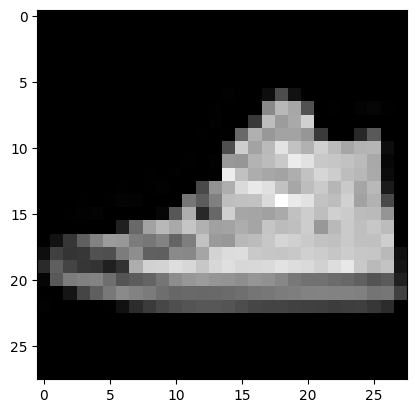

In [ ]:
plt.imshow(images[142], cmap='gray')

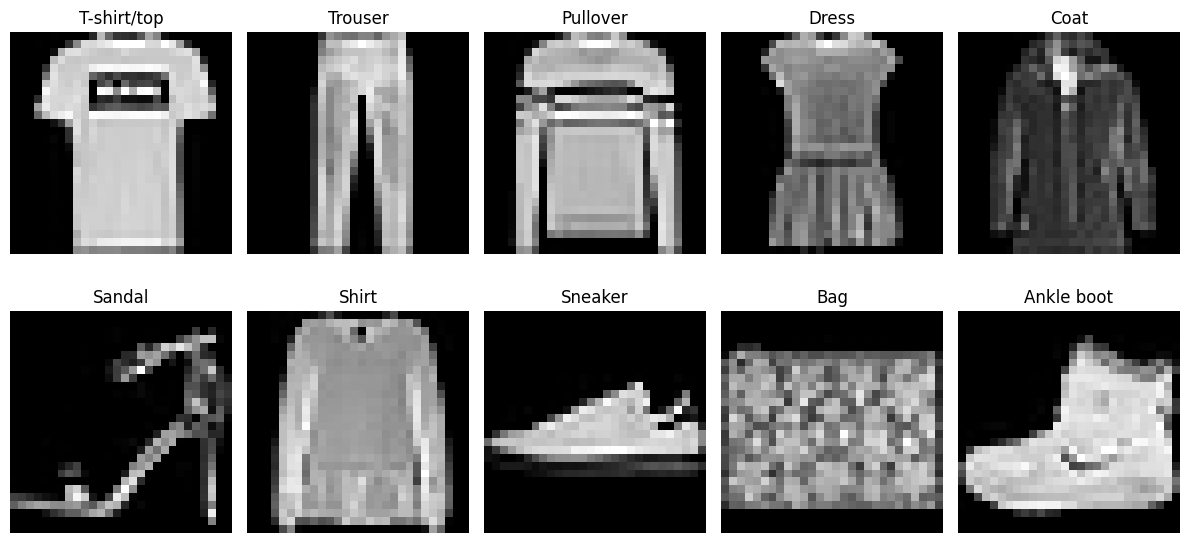

In [ ]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


unique_indices = []
for target_class in range(10):
    for idx, label in enumerate(labels):
        if int(label) == target_class:
            unique_indices.append(idx)
            break

plt.figure(figsize=(12, 6))

for i, idx in enumerate(unique_indices):
    plt.subplot(2, 5, i + 1)

    plt.imshow(images[idx], cmap='gray')

    plt.title(class_names[i], fontsize=12)

    plt.axis('off')

plt.tight_layout()

plt.show()

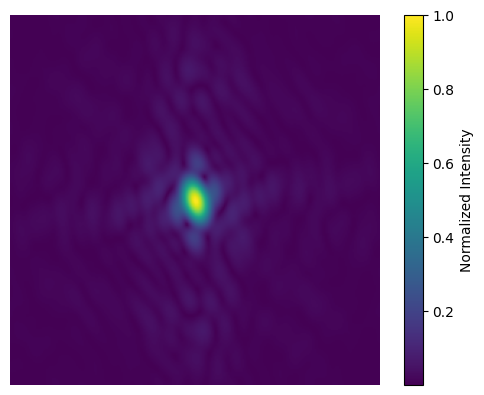

In [ ]:
test_img_preview = pad_image(images[142])
ft_test_img_preview = np.fft.fftshift(np.fft.fft2(test_img_preview))

max_intensity = np.max(np.abs(ft_test_img_preview))

plt.imshow(np.abs(ft_test_img_preview)/max_intensity)
plt.axis('off')
cbar = plt.colorbar()
cbar.set_label('Normalized Intensity')

In [ ]:
r = 35

h, w   = test_img_preview.shape
Y, X   = np.ogrid[:h, :w]
cx, cy = h//2, w//2

dist_sq = (X-cx)**2 + (Y-cy)**2

mask = create_circular_mask(h, w, 3, 35, mask_type = 'highpass')

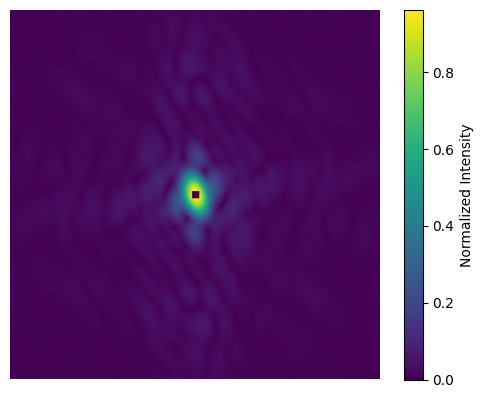

In [ ]:
plt.imshow(np.abs(mask*ft_test_img_preview)/max_intensity, cmap="viridis")
plt.axis('off')
cbar = plt.colorbar()
cbar.set_label('Normalized Intensity')

In [ ]:
ft_img_with_filter = mask * ft_test_img_preview
recovered_image = np.fft.ifft2(np.fft.ifftshift(ft_img_with_filter))[108:148, 108:148]

(np.float64(-0.5), np.float64(39.5), np.float64(39.5), np.float64(-0.5))

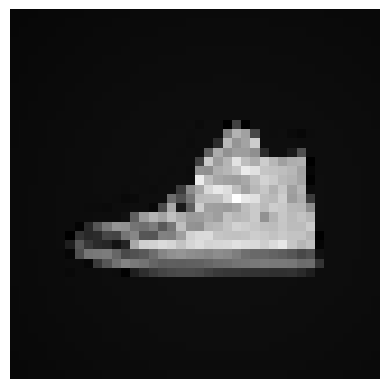

In [ ]:
plt.imshow(np.abs(recovered_image), cmap="gray")
plt.axis('off')

#### **Configurando la aplicación de los filtros High, Low, Complete y POF con parámetros ajustables**

Generando filtros promediados para mejorar robustez...
Cargando índices de prueba estructurados...
Iniciando clasificación de 1000 imágenes (10 por clase)...
Iniciando clasificación de 1000 imágenes (256x256)...

   CLASSIFICATION METRICS (1 TRAINING TUPLE)
Global precision (Accuracy): 0.6110

Detailed report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.69      0.74      0.71       100
           1       0.72      0.96      0.82       100
           2       0.45      0.25      0.32       100
           3       0.71      0.68      0.69       100
           4       0.40      0.34      0.37       100
           5       1.00      0.18      0.31       100
           6       0.33      0.47      0.39       100
           7       0.52      0.91      0.66       100
           8       0.97      0.77      0.86       100
           9       0.73      0.81      0.77       100

    accuracy                           0.61      1000
   macro

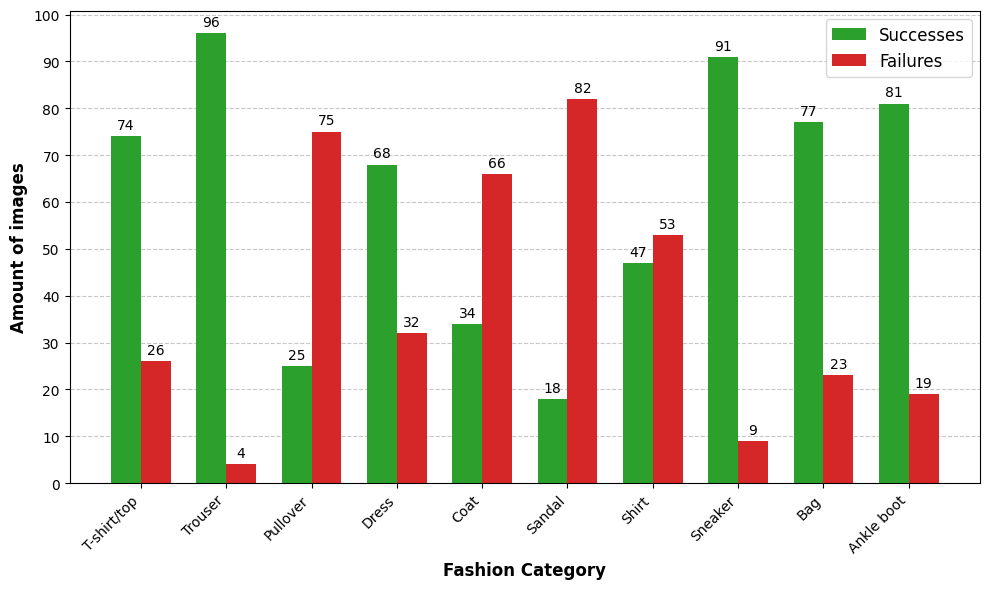

In [ ]:

reference_images = {}

for i in range(10):
    # Tomamos las primeras 20 imágenes de cada clase para hacer promedio
    idxs = np.where(labels == i)[0][:2]

    avg_template = np.mean([pad_image(images[idx]) for idx in idxs], axis=0)

    # Normalizando la energía del filtro promedio
    total_energy = np.sqrt(np.sum(avg_template**2))
    reference_images[i] = avg_template / (total_energy + 1e-12)


print("Cargando índices de prueba estructurados")
try:
    # Cargamos los índices previamente guardados para asegurar reproducibilidad
    indices_prueba = np.load('indices_muestra_1000.npy')
except FileNotFoundError:
    raise FileNotFoundError("Error: No se encontró 'indices_muestra_100.npy'. Ejecuta primero el script de selección.")

y_true = []
y_pred = []

print(f"Iniciando clasificación de {len(indices_prueba)} imágenes (10 por clase)...")


y_true = []
y_pred = []

print(f"Iniciando clasificación de {len(indices_prueba)} imágenes (256x256)...")

for count, idx in enumerate(indices_prueba):
    test_img = pad_image(images_test[idx])
    true_label = int(labels_test[idx])

    # Normalización de energía
    test_energy = np.sqrt(np.sum(test_img**2))
    if test_energy > 0:
        test_img = test_img / test_energy

    peak_intensities = np.zeros(10)

    for i in range(10):
        I_out = optical_correlator(
            test_img,
            reference_images[i],
            apply_iris=True,
            r_in=3,
            r_out=35,
            mask_type='highpass'
        )
        peak_intensities[i] = np.max(I_out)

    # El más probable es el índice con el pico de intensidad más alto
    predicted_digit = np.argmax(peak_intensities)

    y_true.append(true_label)
    y_pred.append(predicted_digit)

# Cálculo de métricas

print("\n" + "="*45)
print("   CLASSIFICATION METRICS (1 TRAINING TUPLE)")
print("="*45)
print(f"Global precision (Accuracy): {accuracy_score(y_true, y_pred):.4f}\n")

print("Detailed report (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

aciertos = np.zeros(10)
desaciertos = np.zeros(10)

for i in range(10):
    mask = (y_true_np == i)
    aciertos[i] = np.sum(y_pred_np[mask] == i)
    desaciertos[i] = np.sum(y_pred_np[mask] != i)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, aciertos, width, label='Successes', color='#2ca02c')
rects2 = ax.bar(x + width/2, desaciertos, width, label='Failures', color='#d62728')

ax.set_xlabel('Fashion Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Amount of images', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')

max_y = max(np.max(aciertos + desaciertos), 10)
ax.set_yticks(np.arange(0, max_y + 10, max_y // 10 if max_y >= 10 else 1))

ax.legend(fontsize=12)

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

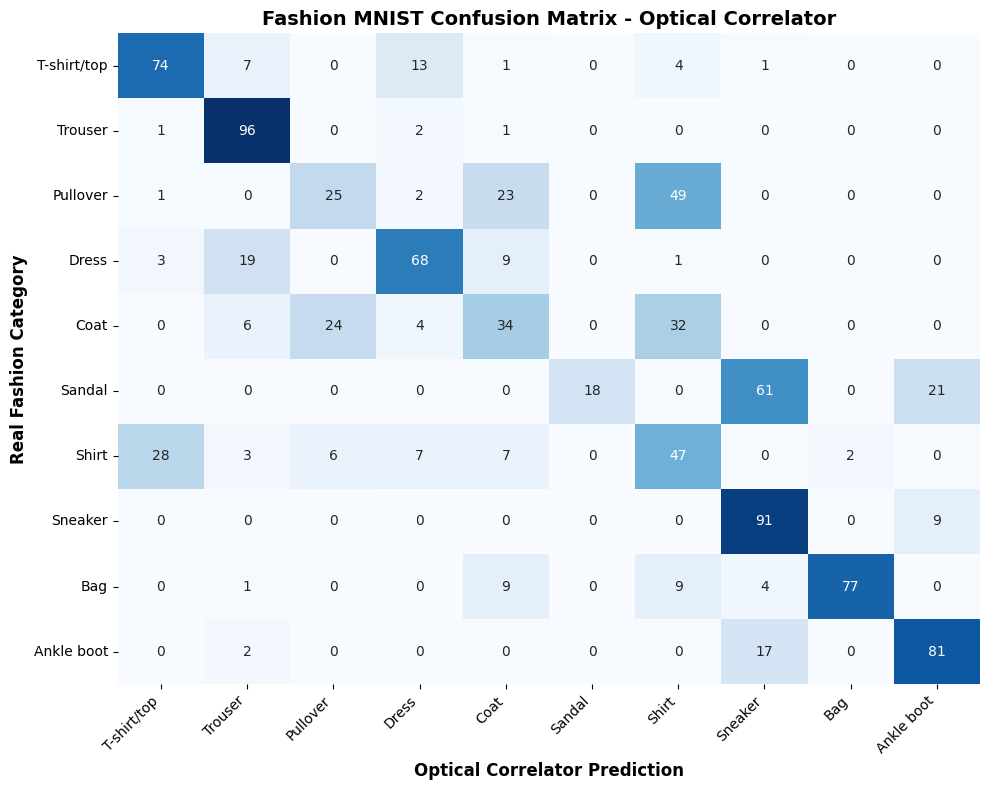

In [ ]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Optical Correlator Prediction', fontsize=12, fontweight='bold')
plt.ylabel('Real Fashion Category', fontsize=12, fontweight='bold')
plt.title('Fashion MNIST Confusion Matrix - Optical Correlator', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# **Profiling MNIST Fashion**

[codecarbon WARNING @ 23:38:02] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 23:38:02] [setup] RAM Tracking...
[codecarbon INFO @ 23:38:02] [setup] CPU Tracking...


Generando filtros promediados para mejorar robustez...


[codecarbon WARNING @ 23:38:03] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 23:38:03] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 23:38:03] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 23:38:03] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 23:38:03] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 23:38:03] [setup] GPU Tracking...
[codecarbon INFO @ 23:38:03] No GPU found.
[codecarbon INFO @ 23:38:03] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: Unspecifie

Cargando índices de prueba estructurados...
Iniciando clasificación de 1000 imágenes (10 por clase)...
Iniciando clasificación de 1000 imágenes (256x256)...


[codecarbon WARNING @ 23:38:06] Unable to access geographical location through primary API. Will resort to using the backup API - Exception : Region is empty - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon INFO @ 23:38:06] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 23:38:08] Energy consumed for RAM : 0.000006 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:38:09] Delta energy consumed for CPU with cpu_load : 0.000004 kWh, power : 8.0 W
[codecarbon INFO @ 23:38:09] Energy consumed for All CPU : 0.000004 kWh
[codecarbon INFO @ 23:38:09] 0.000010 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:38:09] Energy consumed for RAM : 0.000007 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:38:10] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 8.0 W
[codecarbon INFO @ 23:38:10] Energy consumed for All CPU : 0.000006 kWh
[codecarbon INFO @ 23:38:10] 0.000012 kWh of electricity and 0.0


   PERFIL DE RECURSOS (RESOURCE PROFILING)
FASE DE ENTRENAMIENTO (Generación de filtros):
  - Tiempo de ejecución : 0.2193 segundos
  - Consumo de RAM (Est): 46.98 MB
  - Energía consumida   : 0.000005 kWh

FASE DE EVALUACIÓN (Correlación):
  - Tiempo de ejecución : 89.3830 segundos
  - Consumo de RAM (Est): 0.34 MB
  - Energía consumida   : 0.000184 kWh

   CLASSIFICATION METRICS (1 TRAINING TUPLE)
Global precision (Accuracy): 0.6430

Detailed report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.66      0.79      0.72       100
           1       0.95      0.94      0.94       100
           2       0.53      0.39      0.45       100
           3       0.68      0.88      0.77       100
           4       0.39      0.60      0.47       100
           5       0.92      0.22      0.35       100
           6       0.30      0.09      0.14       100
           7       0.54      0.90      0.68       100
           8       0.95  

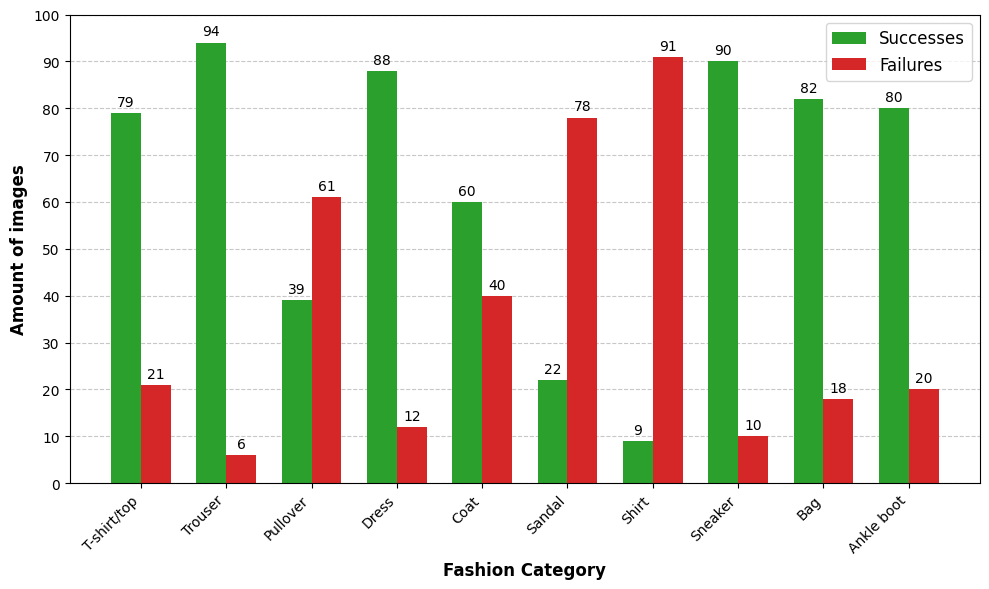

In [ ]:

process = psutil.Process(os.getpid())

reference_images = {}
print("Generando filtros promediados para mejorar robustez...")

tracker_train = EmissionsTracker(project_name="Fashion_Optical_Training", measure_power_secs=1)
tracker_train.start()
start_time_train = time.perf_counter()
mem_before_train = process.memory_info().rss / (1024 * 1024)

for i in range(10):
    idxs = np.where(labels == i)[0][:50]
    avg_template = np.mean([pad_image(images[idx]) for idx in idxs], axis=0)
    total_energy = np.sqrt(np.sum(avg_template**2))
    reference_images[i] = avg_template / (total_energy + 1e-12)

mem_after_train = process.memory_info().rss / (1024 * 1024)
end_time_train = time.perf_counter()
emissions_train = tracker_train.stop()

train_time = end_time_train - start_time_train
train_ram = mem_after_train - mem_before_train
train_energy_kwh = tracker_train.final_emissions_data.energy_consumed

print("Cargando índices de prueba estructurados...")
try:
    indices_prueba = np.load('indices_muestra_1000.npy')
except FileNotFoundError:
    raise FileNotFoundError("Error: No se encontró 'indices_muestra_1000.npy'. Ejecuta primero el script de selección.")

print(f"Iniciando clasificación de {len(indices_prueba)} imágenes (10 por clase)...")

y_true = []
y_pred = []

print(f"Iniciando clasificación de {len(indices_prueba)} imágenes (256x256)...")

tracker_eval = EmissionsTracker(project_name="Fashion_Optical_Eval", measure_power_secs=1)
tracker_eval.start()
start_time_eval = time.perf_counter()
mem_before_eval = process.memory_info().rss / (1024 * 1024)

for count, idx in enumerate(indices_prueba):
    test_img = pad_image(images_test[idx])
    true_label = int(labels_test[idx])

    test_energy = np.sqrt(np.sum(test_img**2))
    if test_energy > 0:
        test_img = test_img / test_energy

    peak_intensities = np.zeros(10)

    for i in range(10):
        I_out = optical_correlator(
            test_img,
            reference_images[i],
            apply_iris=True,
            r_in=3,
            r_out=35,
            mask_type='highpass'
        )
        peak_intensities[i] = np.max(I_out)

    predicted_digit = np.argmax(peak_intensities)
    y_true.append(true_label)
    y_pred.append(predicted_digit)

mem_after_eval = process.memory_info().rss / (1024 * 1024)
end_time_eval = time.perf_counter()
emissions_eval = tracker_eval.stop()

eval_time = end_time_eval - start_time_eval
eval_ram = mem_after_eval - mem_before_eval
eval_energy_kwh = tracker_eval.final_emissions_data.energy_consumed

print("\n" + "="*45)
print("   PERFIL DE RECURSOS (RESOURCE PROFILING)")
print("="*45)
print("FASE DE ENTRENAMIENTO (Generación de filtros):")
print(f"  - Tiempo de ejecución : {train_time:.4f} segundos")
print(f"  - Consumo de RAM (Est): {train_ram:.2f} MB")
print(f"  - Energía consumida   : {train_energy_kwh:.6f} kWh")

print("\nFASE DE EVALUACIÓN (Correlación):")
print(f"  - Tiempo de ejecución : {eval_time:.4f} segundos")
print(f"  - Consumo de RAM (Est): {eval_ram:.2f} MB")
print(f"  - Energía consumida   : {eval_energy_kwh:.6f} kWh")

print("\n" + "="*45)
print("   CLASSIFICATION METRICS (1 TRAINING TUPLE)")
print("="*45)
print(f"Global precision (Accuracy): {accuracy_score(y_true, y_pred):.4f}\n")

print("Detailed report (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

aciertos = np.zeros(10)
desaciertos = np.zeros(10)

for i in range(10):
    mask = (y_true_np == i)
    aciertos[i] = np.sum(y_pred_np[mask] == i)
    desaciertos[i] = np.sum(y_pred_np[mask] != i)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, aciertos, width, label='Successes', color='#2ca02c')
rects2 = ax.bar(x + width/2, desaciertos, width, label='Failures', color='#d62728')

ax.set_xlabel('Fashion Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Amount of images', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')

max_y = max(np.max(aciertos + desaciertos), 10)
ax.set_yticks(np.arange(0, max_y + 10, max_y // 10 if max_y >= 10 else 1))

ax.legend(fontsize=12)

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Ahora, para todas las tuplas de entrenamiento y prueba

[codecarbon WARNING @ 23:39:38] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 23:39:38] [setup] RAM Tracking...
[codecarbon INFO @ 23:39:38] [setup] CPU Tracking...
[codecarbon WARNING @ 23:39:38] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 23:39:38] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 23:39:38] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 23:39:38] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 23:39:38] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 23:39:38] [setup] GPU Tracking...
[codecarbon INFO @ 23:39:38] No GPU found.
[codecarbon INFO @ 23:3

Generando filtros promediados usando TODO el dataset de entrenamiento (60,000 imágenes)...


[codecarbon INFO @ 23:39:38] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 23:39:40] Energy consumed for RAM : 0.000006 kWh. RAM Power : 10.0 W


Filtro de la clase 0 generado (6000 imágenes promediadas).


[codecarbon INFO @ 23:39:40] Delta energy consumed for CPU with cpu_load : 0.000004 kWh, power : 7.5765823999999995 W
[codecarbon INFO @ 23:39:40] Energy consumed for All CPU : 0.000004 kWh
[codecarbon INFO @ 23:39:40] 0.000010 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:39:41] Energy consumed for RAM : 0.000007 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:39:41] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 1.7550872000000004 W
[codecarbon INFO @ 23:39:41] Energy consumed for All CPU : 0.000004 kWh
[codecarbon INFO @ 23:39:41] 0.000011 kWh of electricity and 0.000000 L of water were used since the beginning.


...

Progreso: 9000 / 10000 imágenes procesadas...


[codecarbon INFO @ 23:52:02] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 2.3668639999999996 W
[codecarbon INFO @ 23:52:02] Energy consumed for All CPU : 0.000340 kWh
[codecarbon INFO @ 23:52:02] 0.001338 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:52:02] Energy consumed for RAM : 0.000999 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:52:03] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 2.0692736 W
[codecarbon INFO @ 23:52:03] Energy consumed for All CPU : 0.000341 kWh
[codecarbon INFO @ 23:52:03] 0.001340 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:52:03] Energy consumed for RAM : 0.001001 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:52:04] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 1.9655261 W
[codecarbon INFO @ 23:52:04] Energy consumed for All CPU : 0.000341 kWh
[codecarbon INFO @ 23:52:04] 0.001341 kWh of ele

Progreso: 10000 / 10000 imágenes procesadas...


[codecarbon INFO @ 23:53:25] Delta energy consumed for CPU with cpu_load : 0.000002 kWh, power : 6.572708640800003 W
[codecarbon INFO @ 23:53:25] Energy consumed for All CPU : 0.000380 kWh
[codecarbon INFO @ 23:53:25] 0.001493 kWh of electricity and 0.000000 L of water were used since the beginning.



   PERFIL DE RECURSOS (DATASET COMPLETO)
FASE DE ENTRENAMIENTO (60,000 imágenes):
  - Tiempo de ejecución : 8.9182 segundos
  - Consumo de RAM (Est): 0.00 MB
  - Energía consumida   : 0.000022 kWh

FASE DE EVALUACIÓN (10,000 imágenes):
  - Tiempo de ejecución : 815.1740 segundos
  - Consumo de RAM (Est): 0.35 MB
  - Energía consumida   : 0.001493 kWh

   MÉTRICAS DE CLASIFICACIÓN FINAL
Precisión global (Accuracy): 0.6523

Reporte detallado (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      1000
           1       0.96      0.91      0.93      1000
           2       0.54      0.57      0.55      1000
           3       0.66      0.88      0.76      1000
           4       0.46      0.60      0.52      1000
           5       0.79      0.19      0.31      1000
           6       0.40      0.14      0.21      1000
           7       0.56      0.94      0.70      1000
           8       0.89      0.72    

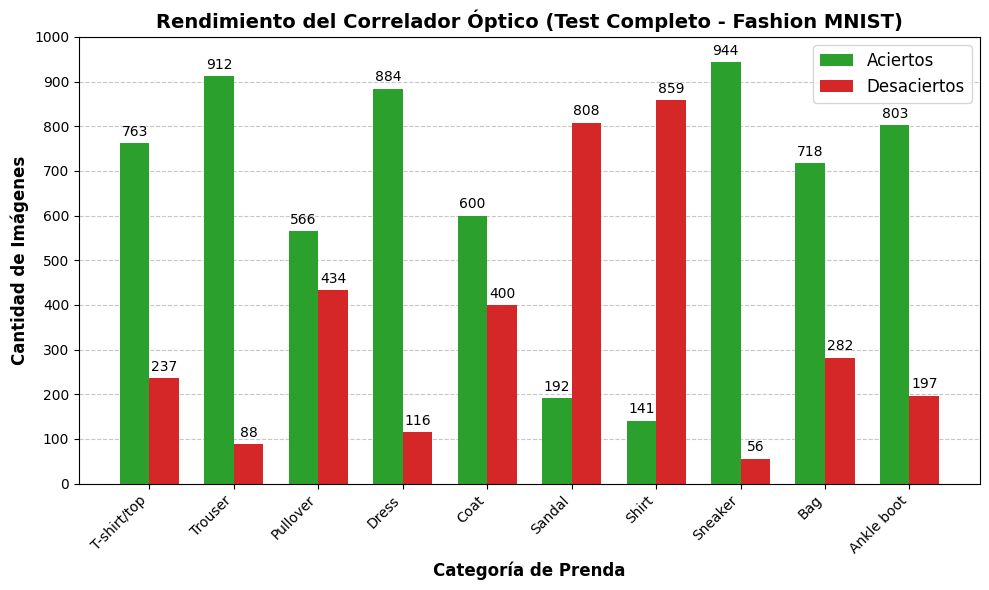

In [ ]:

process = psutil.Process(os.getpid())

reference_images = {}
print("Generando filtros promediados usando todo el dataset de entrenamiento (60,000 imágenes)...")

tracker_train = EmissionsTracker(project_name="Fashion_Full_Training", measure_power_secs=1)
tracker_train.start()
start_time_train = time.perf_counter()
mem_before_train = process.memory_info().rss / (1024 * 1024)

for i in range(10):
    idxs = np.where(labels == i)[0]

    forma_base = pad_image(images[idxs[0]]).shape
    avg_template = np.zeros(forma_base, dtype=float)

    for idx in idxs:
        avg_template += pad_image(images[idx])

    avg_template /= len(idxs)

    total_energy = np.sqrt(np.sum(avg_template**2))
    reference_images[i] = avg_template / (total_energy + 1e-12)

    print(f"Filtro de la clase {i} generado ({len(idxs)} imágenes promediadas).")

mem_after_train = process.memory_info().rss / (1024 * 1024)
end_time_train = time.perf_counter()
emissions_train = tracker_train.stop()

train_time = end_time_train - start_time_train
train_ram = mem_after_train - mem_before_train
train_energy_kwh = tracker_train.final_emissions_data.energy_consumed

y_true = []
y_pred = []
total_test_images = len(images_test)

print(f"\nIniciando clasificación de {total_test_images} imágenes de prueba (esto tomará varios minutos)...")

tracker_eval = EmissionsTracker(project_name="Fashion_Full_Eval", measure_power_secs=1)
tracker_eval.start()
start_time_eval = time.perf_counter()
mem_before_eval = process.memory_info().rss / (1024 * 1024)

for idx in range(total_test_images):
    test_img = pad_image(images_test[idx])
    true_label = int(labels_test[idx])

    test_energy = np.sqrt(np.sum(test_img**2))
    if test_energy > 0:
        test_img = test_img / test_energy

    peak_intensities = np.zeros(10)

    for i in range(10):
        I_out = optical_correlator(
            test_img,
            reference_images[i],
            apply_iris=True,
            r_in=3,
            r_out=35,
            mask_type='highpass'
        )
        peak_intensities[i] = np.max(I_out)

    predicted_digit = np.argmax(peak_intensities)
    y_true.append(true_label)
    y_pred.append(predicted_digit)

    if (idx + 1) % 1000 == 0:
        print(f"Progreso: {idx + 1} / {total_test_images} imágenes procesadas...")

mem_after_eval = process.memory_info().rss / (1024 * 1024)
end_time_eval = time.perf_counter()
emissions_eval = tracker_eval.stop()

eval_time = end_time_eval - start_time_eval
eval_ram = mem_after_eval - mem_before_eval
eval_energy_kwh = tracker_eval.final_emissions_data.energy_consumed

print("\n" + "="*50)
print("   Perfil de recursos (dataset completo)")
print("="*50)
print("Fase de entrenamiento (60,000 imágenes):")
print(f"  - Tiempo de ejecución : {train_time:.4f} segundos")
print(f"  - Consumo de RAM (est): {train_ram:.2f} MB")
print(f"  - Energía consumida   : {train_energy_kwh:.6f} kWh")

print("\nFase de evaluación (10,000 imágenes):")
print(f"  - Tiempo de ejecución : {eval_time:.4f} segundos")
print(f"  - Consumo de RAM (est): {eval_ram:.2f} MB")
print(f"  - Energía consumida   : {eval_energy_kwh:.6f} kWh")

print("\n" + "="*50)
print("   Métricas de clasificación final")
print("="*50)
print(f"Precisión global (accuracy): {accuracy_score(y_true, y_pred):.4f}\n")

print("Reporte detallado (precision, recall, f1-score):")
print(classification_report(y_true, y_pred))

y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

aciertos = np.zeros(10)
desaciertos = np.zeros(10)

for i in range(10):
    mask = (y_true_np == i)
    aciertos[i] = np.sum(y_pred_np[mask] == i)
    desaciertos[i] = np.sum(y_pred_np[mask] != i)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, aciertos, width, label='Aciertos', color='#2ca02c')
rects2 = ax.bar(x + width/2, desaciertos, width, label='Desaciertos', color='#d62728')

ax.set_xlabel('Categoría de Prenda', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Imágenes', fontsize=12, fontweight='bold')
ax.set_title('Rendimiento del Correlador Óptico (Test Completo - Fashion MNIST)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')

max_y = max(np.max(aciertos + desaciertos), 1000)
ax.set_yticks(np.arange(0, max_y + 100, 100))

ax.legend(fontsize=12)
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

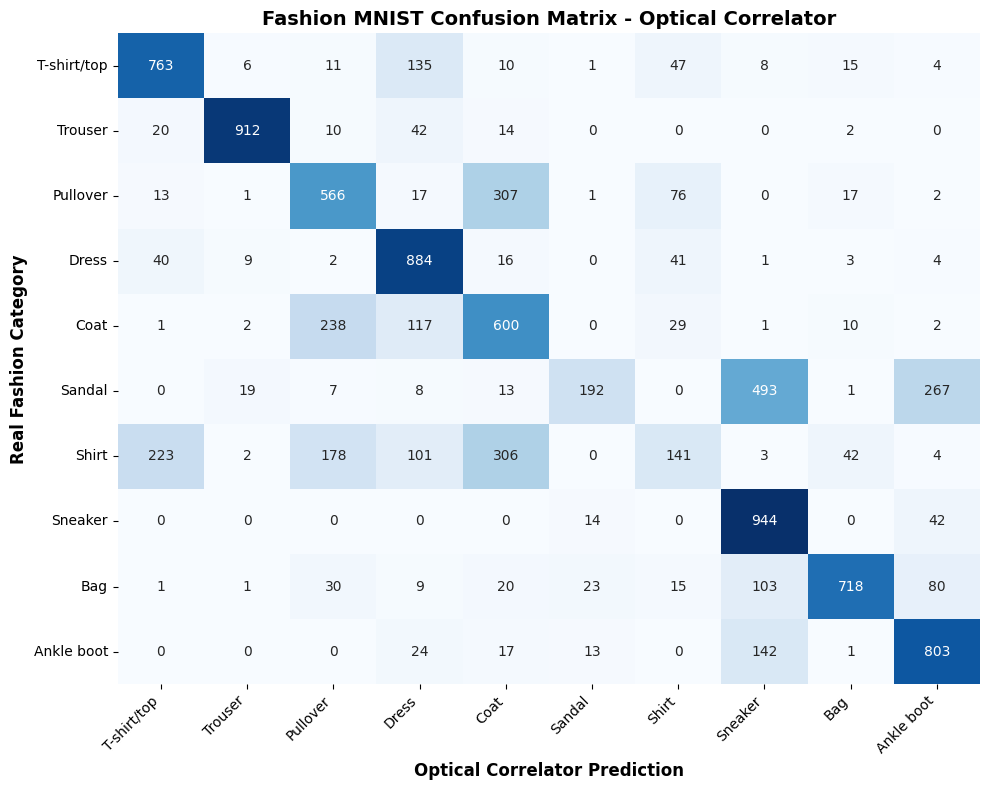

In [ ]:
# 1. Definir la lista oficial de nombres de las categorías de Fashion MNIST
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Calculamos la matriz de confusión usando tus arreglos de la simulación
cm = confusion_matrix(y_true, y_pred)

# Configuramos la figura
plt.figure(figsize=(10, 8))

# 2. Reemplazamos range(10) por nuestra lista class_names
# Conservamos annot=True y fmt='d' para ver la cantidad exacta de imágenes clasificadas
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)

# 3. Ajustamos las etiquetas y títulos (Cambiamos "Real Digit" por "Real Category")
plt.xlabel('Optical Correlator Prediction', fontsize=12, fontweight='bold')
plt.ylabel('Real Fashion Category', fontsize=12, fontweight='bold')
plt.title('Fashion MNIST Confusion Matrix - Optical Correlator', fontsize=14, fontweight='bold')

# 4. Rotamos las etiquetas del eje X 45 grados para que quepan bien y se vean profesionales
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0) # Mantiene las del eje Y completamente horizontales

plt.tight_layout()
plt.show()